Assignment 1 -------
IT Support Coordinator -------------

In [1]:
import os
from dotenv import load_dotenv
load_dotenv()

True

In [2]:
from langchain_openai import ChatOpenAI

c:\dev\lv-assignment1\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
from langchain_core.messages import SystemMessage, HumanMessage, AIMessage
from langgraph.graph import StateGraph,START,END,MessagesState
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition
from IPython.display import Image, display
from langgraph.checkpoint.memory import MemorySaver
import random

In [4]:
llm=ChatOpenAI(model="gpt-4o-mini")

In [5]:
def server_status() -> str:
    """
    This Function checks the server status and returns either "online" or "offline".
    """
    _val=random.choice(["online","offline"])
    return _val

In [6]:
def restart_server() -> str:
    """
    This Function restarts the server 
    """
    return "The server is restarted successfully"

tool = [server_status,restart_server]
function = ToolNode(tool)

In [7]:
llm_with_tools=llm.bind_tools(tool)

In [8]:
prompt = """
You are a helpful IT helpdesk assistant. You will be supporting the client with their IT request.
Any question other than IT support should be politely declined.
As an IT helpdesk assistant, you have access to the following tools:
1. If the client ask for a server status, Pls ask the server name from the client.
after receiving the server name, pls use the "server_status" tool to check the server status
and report back to the client.
2. if server name is not given, politely ask client to give the name to proceed.
3. if the tool outcome is offline, pls respond with the server name and inform the client the status.
4. In case the server is offline, ask the client if they want to restart the server.
5. if the server is online, pls respond with the server name and inform the client the status, and ask if there is anything else you can help with.
3. if the client asks to restart the server, in case the server is offline,
pls use the "restart_server" tool to restart the server and report back to the client.
4. if the client did not ask for restart, pls do not restart the server, even if the server is offline. 
Always ask the client before restarting the server.
"""

In [9]:
system_message = SystemMessage(content=prompt)

In [10]:
def state_node(state: MessagesState):
    user_message = state["messages"]
    question=[system_message]+user_message
    response = llm_with_tools.invoke(question)
    return {
        "messages":[response]
    }

In [11]:
memory=MemorySaver()

In [12]:
graph = StateGraph(MessagesState)
graph.add_node("IT Assistant",state_node)
graph.add_node("tools",function)
graph.add_edge(START,"IT Assistant")
graph.add_conditional_edges(
    "IT Assistant",
    tools_condition,
)
graph.add_edge("tools","IT Assistant")
app = graph.compile(checkpointer=memory)

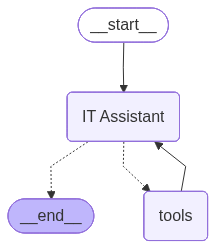

In [13]:
display(Image(app.get_graph(xray=True).draw_mermaid_png()))

In [22]:
config = {"configurable":{"thread_id":"13"}}

In [23]:
response=app.invoke({
    "messages": [   
        HumanMessage(  
            content="My email server is acting up"
        )
    ]},config=config)

In [24]:
for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

My email server is acting up
================================== Ai Message ==================================

Could you please provide the name of the email server so I can check its status?


In [26]:
response=app.invoke({
    "messages": [   
        HumanMessage(  
            content="Server - alpha"
        )
    ]},config=config)

In [27]:
for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

My email server is acting up
================================== Ai Message ==================================

Could you please provide the name of the email server so I can check its status?
================================ Human Message =================================

Server - alpha
================================== Ai Message ==================================
Tool Calls:
  server_status (call_LBe29mxLJCwQoGDZcleR9Ffr)
 Call ID: call_LBe29mxLJCwQoGDZcleR9Ffr
  Args:
================================= Tool Message =================================
Name: server_status

offline
================================== Ai Message ==================================

The email server "alpha" is currently offline. Would you like me to restart the server?


In [28]:
response=app.invoke({
    "messages": [   
        HumanMessage(  
            content="pls do the needful"
        )
    ]},config=config)

In [29]:
for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

My email server is acting up
================================== Ai Message ==================================

Could you please provide the name of the email server so I can check its status?
================================ Human Message =================================

Server - alpha
================================== Ai Message ==================================
Tool Calls:
  server_status (call_LBe29mxLJCwQoGDZcleR9Ffr)
 Call ID: call_LBe29mxLJCwQoGDZcleR9Ffr
  Args:
================================= Tool Message =================================
Name: server_status

offline
================================== Ai Message ==================================

The email server "alpha" is currently offline. Would you like me to restart the server?
================================ Human Message =================================

pls do the needful
================================== Ai Message =============

In [83]:
response=app.invoke({
    "messages": [   
        HumanMessage(  
            content="What is the capital of India"
        )
    ]},config=config)

In [84]:
for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

My email server is acting up
================================== Ai Message ==================================

Could you please provide me with the name of the email server so I can check its status?
================================ Human Message =================================

Server - alpha
================================== Ai Message ==================================
Tool Calls:
  server_status (call_rjyKLC854AeiWzbc3fM3WFIg)
 Call ID: call_rjyKLC854AeiWzbc3fM3WFIg
  Args:
================================= Tool Message =================================
Name: server_status

offline
================================== Ai Message ==================================

The email server "alpha" is currently offline. Would you like to restart the server?
================================ Human Message =================================

pls do the needful
================================== Ai Message ========